## Pilot Experiment Notebook (1 Variable at a Time)

This notebook is split from `Experimentation.ipynb` so pilot runs are isolated and faster to iterate.


### Pilot Protocol Update (Fast + Robust)

Why this protocol:
- Full-evacuation time can become unavailable in capped runs when not all agents escape.
- With `max_steps=800`, we track always-defined time-series metrics instead:
  - `escaped_count(t)`
  - `escaped_fraction(t)`

Changes from earlier approach:
- `n_runs=3`
- `max_steps=800`
- Run one test case at a time via `ACTIVE_TC`
- Plot progress-over-time instead of relying on completion-only metrics


In [2]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\kylet\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# imports + paths
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = Path(r"C:\Users\kylet\HTX\Deliverable 1\FYP-Generative-Agent-Evacuation-Simulation")
EXPERIMENTS = REPO / "experiments"

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import pysocialforce as psf

CONFIG_FILE = EXPERIMENTS / "example.toml"
BEHAVIOR_FILE = EXPERIMENTS / "behavior_grid.json"
GROUP_BEHAVIOR_FILE = EXPERIMENTS / "behavior_grid_grouping.json"


In [4]:
# core helpers
def generate_random_positions(n_agents, room_size=20.0, margin=2.0):
    return np.random.uniform(
        low=-room_size/2 + margin,
        high=room_size/2 - margin,
        size=(n_agents, 2),
    )

def generate_characteristics(n_agents):
    age_categories = ["Young Adult", "Adult", "Middle Age"]
    genders = ["male", "female"]
    trait_levels = ["Low", "High"]
    chars = []
    for _ in range(n_agents):
        traits = [np.random.choice(trait_levels) for _ in range(5)]
        chars.append([np.random.choice(age_categories), np.random.choice(genders)] + traits)
    return chars

def create_initial_groups(positions, characteristics, behavior_grid_grouping_path, max_group_size=5, group_distance=1.2):
    with open(behavior_grid_grouping_path, "r", encoding="utf-8") as f:
        behavior_grid_group = json.load(f)

    n_agents = len(positions)
    group_preferences = []

    for chars in characteristics:
        age_cat, gender, o, c, e, a, n = chars
        pref = "Solo"
        for behavior in behavior_grid_group:
            if (
                behavior["age_category"] == age_cat
                and behavior["gender"] == gender
                and behavior["traits"]["Openness"] == o
                and behavior["traits"]["Conscientiousness"] == c
                and behavior["traits"]["Extraversion"] == e
                and behavior["traits"]["Agreeableness"] == a
                and behavior["traits"]["Neuroticism"] == n
            ):
                pref = behavior["group_preference"]
                break
        group_preferences.append(pref)

    dmat = np.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=2)
    groups, used = [], set()

    for i in range(n_agents):
        if i in used or group_preferences[i] == "Solo":
            continue
        cand = [i]
        for j in range(i + 1, n_agents):
            if j not in used and group_preferences[j] == "Group" and dmat[i, j] < group_distance:
                cand.append(j)
        if len(cand) > 1:
            g = cand[:max_group_size]
            groups.append(g)
            used.update(g)

    return groups

def create_square_room_w_n_exits(size=20.0, n_exits=1, door_width=1.2, edge_margin=0.6):
    half = size / 2.0
    y_min, y_max = -half, half
    usable = (y_max - y_min) - 2 * edge_margin
    if n_exits * door_width >= usable:
        raise ValueError("Too many/wide exits for this room size.")

    centers = np.linspace(y_min + edge_margin + door_width/2, y_max - edge_margin - door_width/2, n_exits)
    gaps = [(c - door_width/2, c + door_width/2) for c in centers]

    walls = [
        [-half, half, -half, -half],
        [-half, half, half, half],
        [-half, -half, -half, half],
    ]
    x = half
    cursor = y_min
    for g0, g1 in gaps:
        if g0 > cursor:
            walls.append([x, x, cursor, g0])
        cursor = g1
    if cursor < y_max:
        walls.append([x, x, cursor, y_max])

    return walls


In [5]:
# pilot simulation function (time-series output)
def run_timeseries(
    model="baseline",
    n_agents=50,
    door_width=1.2,
    n_exits=1,
    room_size=20.0,
    panic_speed=1.5,
    tau=0.5,
    max_steps=800,
    seed=42,
    keep_traj_every=20,
):
    np.random.seed(seed)
    model_key = {"behavioural": "behavioral"}.get(str(model).strip().lower(), str(model).strip().lower())

    pos0 = generate_random_positions(n_agents, room_size=room_size)
    final_goal = np.array([room_size/2 + 3.0, 0.0])
    goals = np.tile(final_goal, (n_agents, 1))
    obstacles = create_square_room_w_n_exits(size=room_size, n_exits=n_exits, door_width=door_width)

    vel0 = np.zeros((n_agents, 2))
    for i in range(n_agents):
        d = final_goal - pos0[i]
        d = d / np.linalg.norm(d)
        vel0[i] = d * panic_speed

    if model_key == "baseline":
        init = np.zeros((n_agents, 6), dtype=float)
        init[:, :2], init[:, 2:4], init[:, 4:6] = pos0, vel0, goals
        sim = psf.Simulator(
            init, groups=None, obstacles=obstacles, config_file=CONFIG_FILE,
            ped_state_class=psf.sceneforevacuation.PedStateEvacuation,
            env_state_class=psf.sceneforevacuation.EnvStateEvacuation
        )
    else:
        init = np.empty((n_agents, 14), dtype=object)
        init[:, :2], init[:, 2:4], init[:, 4:6], init[:, 6] = pos0, vel0, goals, tau
        chars = generate_characteristics(n_agents)
        for i, c in enumerate(chars):
            init[i, 7:] = c

        if model_key == "behavioral":
            sim = psf.SimulatorWithBehavior(
                init, groups=None, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        elif model_key == "group":
            groups = create_initial_groups(pos0, chars, GROUP_BEHAVIOR_FILE)
            sim = psf.SimulatorWithGroup(
                init, groups=groups, obstacles=obstacles,
                config_file=CONFIG_FILE, behavior_file=BEHAVIOR_FILE
            )
        else:
            raise ValueError(f"Unknown model '{model}'")

    curve_rows = []
    traj_rows = []

    for step in range(max_steps + 1):
        escaped = int(np.sum(sim.peds.escaped))
        curve_rows.append({
            "step": step,
            "time_s": step * tau,
            "escaped_count": escaped,
            "escaped_fraction": escaped / n_agents,
        })

        if step % keep_traj_every == 0:
            p = sim.peds.pos()
            for i in range(n_agents):
                traj_rows.append({
                    "step": step,
                    "time_s": step * tau,
                    "agent_id": i,
                    "x": float(p[i, 0]),
                    "y": float(p[i, 1]),
                })

        if step < max_steps:
            sim.step(1)

    final = {
        "model": model_key,
        "n_agents": n_agents,
        "door_width": door_width,
        "n_exits": n_exits,
        "room_size": room_size,
        "panic_speed": panic_speed,
        "seed": seed,
        "escaped_count_final": curve_rows[-1]["escaped_count"],
        "escaped_fraction_final": curve_rows[-1]["escaped_fraction"],
    }

    return pd.DataFrame(curve_rows), pd.DataFrame(traj_rows), final


What is SFM? What are the diff models that people are using?

**Document before moving on**

There are other methods -> go deep into this particular model; but there are other proven ways to do. The FYP is done but it's not properly validated yet. If can find a more suitable paper (i.e. done on a real life scenario). Do this before experimenting further; more comprehensive literature review. If theres no better solution/framework, then we come back to this.

What are the pros & cons of each approach.... don't experiment a project that may not be used. 

In [ ]:
# pilot config - run one test case at a time
# keep in view first; don't delete
CONTROL = dict(n_agents=50, door_width=1.2, n_exits=1, room_size=20.0, panic_speed=1.5)
MODELS = ["baseline", "behavioral", "group"]
N_RUNS = 3
MAX_STEPS = 800
TAU = 0.5

TEST_CASES = {
    "TC0": {"var": "control",     "values": [None]},
    "TC1": {"var": "n_agents",    "values": [50, 100, 500]},
    "TC2": {"var": "door_width",  "values": [1.0, 1.2, 1.6]},
    "TC3": {"var": "n_exits",     "values": [1, 2, 3]},
    "TC4": {"var": "room_size",   "values": [16.0, 20.0, 24.0]},
    "TC5": {"var": "panic_speed", "values": [1.5, 2.0, 3.0]},
}

ACTIVE_TC = "TC1"

# assumption that this is the best model vs this might not be without proper experimentation
# why is it taking so long... where is the bottleneck... is it interacting with each other?


In [7]:
# run active test case
spec = TEST_CASES[ACTIVE_TC]
changed_var = spec["var"]
values = spec["values"]

all_curves, all_traj, all_final = [], [], []

for model in MODELS:
    for v in values:
        for run_i in range(N_RUNS):
            params = CONTROL.copy()
            if changed_var != "control":
                params[changed_var] = v

            df_curve, df_traj, final = run_timeseries(
                model=model,
                max_steps=MAX_STEPS,
                tau=TAU,
                seed=1000 + run_i,
                **params,
            )

            changed_value = "control" if changed_var == "control" else v

            df_curve["test_case"] = ACTIVE_TC
            df_curve["changed_var"] = changed_var
            df_curve["changed_value"] = changed_value
            df_curve["model"] = model
            df_curve["run"] = run_i + 1

            df_traj["test_case"] = ACTIVE_TC
            df_traj["changed_var"] = changed_var
            df_traj["changed_value"] = changed_value
            df_traj["model"] = model
            df_traj["run"] = run_i + 1

            final.update({
                "test_case": ACTIVE_TC,
                "changed_var": changed_var,
                "changed_value": changed_value,
                "run": run_i + 1,
            })

            all_curves.append(df_curve)
            all_traj.append(df_traj)
            all_final.append(final)

            print(f"Done: {model} | {changed_var}={changed_value} | run={run_i+1}")

df_curves = pd.concat(all_curves, ignore_index=True)
df_traj = pd.concat(all_traj, ignore_index=True)
df_final = pd.DataFrame(all_final)

df_curves.to_csv(f"{ACTIVE_TC}_curves.csv", index=False)
df_traj.to_csv(f"{ACTIVE_TC}_traj.csv", index=False)
df_final.to_csv(f"{ACTIVE_TC}_final.csv", index=False)

display(df_final.head())


DEBUG:[byteflow.py:81             __init__() ] bytecode dump:
>          0	NOP(arg=None, lineno=97)
           2	RESUME(arg=0, lineno=97)
           4	LOAD_FAST(arg=0, lineno=101)
           6	LOAD_CONST(arg=1, lineno=101)
           8	LOAD_CONST(arg=1, lineno=101)
          10	BUILD_SLICE(arg=2, lineno=101)
          12	LOAD_CONST(arg=2, lineno=101)
          14	LOAD_CONST(arg=3, lineno=101)
          16	BUILD_SLICE(arg=2, lineno=101)
          18	BUILD_TUPLE(arg=2, lineno=101)
          20	BINARY_SUBSCR(arg=None, lineno=101)
          24	STORE_FAST(arg=1, lineno=101)
          26	LOAD_GLOBAL(arg=1, lineno=102)
          36	LOAD_ATTR(arg=2, lineno=102)
          56	LOAD_FAST(arg=1, lineno=102)
          58	GET_ITER(arg=None, lineno=102)
          60	LOAD_FAST_AND_CLEAR(arg=2, lineno=102)
          62	SWAP(arg=2, lineno=102)
          64	BUILD_LIST(arg=0, lineno=102)
          66	SWAP(arg=2, lineno=102)
>         68	FOR_ITER(arg=33, lineno=102)
          72	STORE_FAST(arg=2, lineno=102

DEBUG: time_since_last_escape = 1, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 2, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 3, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 4, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 5, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 6, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 7, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 8, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
DEBUG: time_since_last_escape = 9, boost_timeout = 50
DEBUG: any_escaped

DEBUG:[byteflow.py:81             __init__() ] bytecode dump:
>          0	NOP(arg=None, lineno=106)
           2	RESUME(arg=0, lineno=106)
           4	LOAD_GLOBAL(arg=1, lineno=109)
          14	LOAD_ATTR(arg=2, lineno=109)
          34	LOAD_FAST(arg=0, lineno=109)
          36	LOAD_CONST(arg=1, lineno=109)
          38	KW_NAMES(arg=2, lineno=109)
          40	CALL(arg=2, lineno=109)
          48	LOAD_FAST(arg=0, lineno=109)
          50	LOAD_ATTR(arg=4, lineno=109)
          70	LOAD_CONST(arg=1, lineno=109)
          72	BINARY_SUBSCR(arg=None, lineno=109)
          76	BINARY_OP(arg=11, lineno=109)
          80	RETURN_VALUE(arg=None, lineno=109)
DEBUG:[byteflow.py:108                  run() ] pending: deque([State(pc_initial=0 nstack_initial=0)])
DEBUG:[byteflow.py:111                  run() ] stack: []
DEBUG:[byteflow.py:112                  run() ] state.pc_initial: State(pc_initial=0 nstack_initial=0)
DEBUG:[byteflow.py:349             dispatch() ] dispatch pc=0, inst=NOP(arg=None

Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 1, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 2, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 3, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Starting Simulation Step ===
Number of active forces: 6
Group forces enabled: True
Computed forces shape: (50, 2)
DEBUG: time_since_last_escape = 4, boost_timeout = 50
DEBUG: any_escaped = False
DEBUG: Condition evaluation: False
=== Simulation Step Complete ===


=== Startin

,model,n_agents,door_width,n_exits,room_size,panic_speed,seed,escaped_count_final,escaped_fraction_final,test_case,changed_var,changed_value,run
0,baseline,50,1.2,1,20.0,1.5,1000,0,0.0,TC1,n_agents,50,1
1,baseline,50,1.2,1,20.0,1.5,1001,0,0.0,TC1,n_agents,50,2
2,baseline,50,1.2,1,20.0,1.5,1002,0,0.0,TC1,n_agents,50,3
3,baseline,100,1.2,1,20.0,1.5,1000,0,0.0,TC1,n_agents,100,1
4,baseline,100,1.2,1,20.0,1.5,1001,0,0.0,TC1,n_agents,100,2


**Why we changed the metrics**
In earlier runs, `evac_time_s` became `NaN` whenever not all agents escaped before `max_steps`.
With a capped simulation (`max_steps=800`), this is common and makes plotting less useful.

So for pilot runs, we switch to **time-series evacuation metrics** that are always defined:
- `escaped_count(t)`: number of agents escaped at step `t`
- `escaped_fraction(t)`: escaped_count / total_agents at step `t`

These metrics let us compare models even when full evacuation is not reached.

**What changed**
- Keep `n_runs = 3` for each setting
- Set `max_steps = 800`
- Run **one test case at a time** (to reduce crash risk and runtime)
- Remove `complete=True/False` from analysis tables and plots
- Plot evacuation progress over time instead of only final evacuation time

**Time unit**
If `tau = 0.5`, then:
- `time_seconds = step * 0.5`

DEBUG:[pyplot.py:497       switch_backend() ] Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:[pyplot.py:497       switch_backend() ] Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:[font_manager.py:1471     _findfont_cached() ] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:[font_manager.py:1483     _findfont_cached() ] findfont: score(FontEntry(fname='C:\\Users\\kylet\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-pa

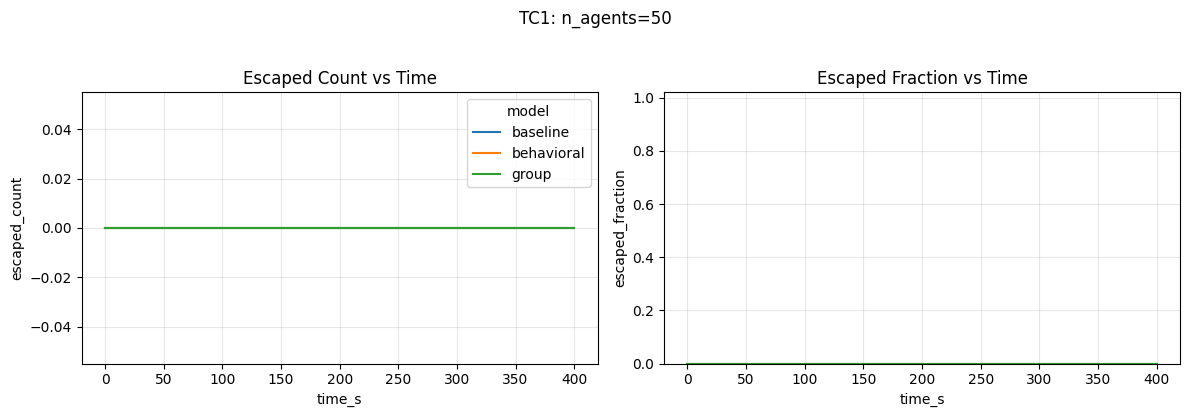

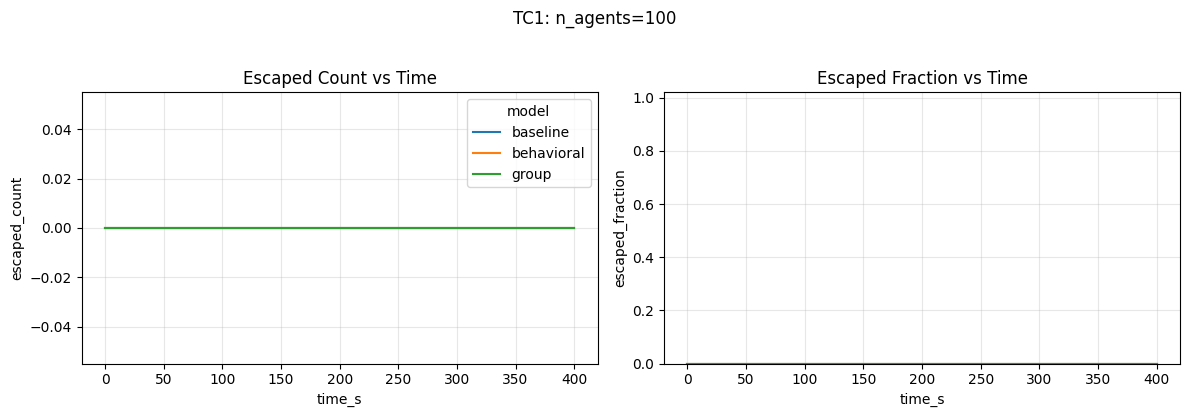

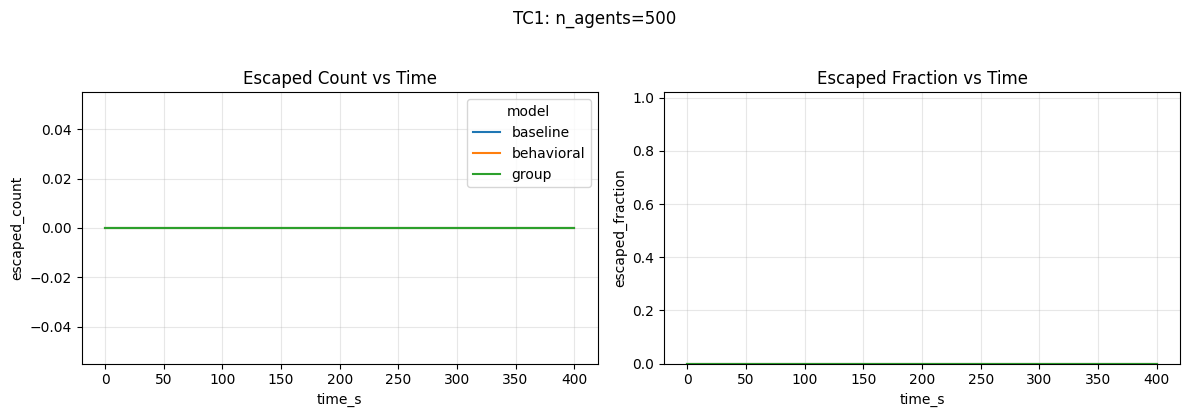

In [8]:
# plot escaped count / fraction over time (mean across runs)
agg = (
    df_curves.groupby(["model", "changed_value", "step", "time_s"], as_index=False)
    .agg(
        escaped_count_mean=("escaped_count", "mean"),
        escaped_fraction_mean=("escaped_fraction", "mean"),
    )
)

for v in sorted(agg["changed_value"].unique()):
    d = agg[agg["changed_value"] == v]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{ACTIVE_TC}: {changed_var}={v}", y=1.03)

    sns.lineplot(data=d, x="time_s", y="escaped_count_mean", hue="model", ax=axes[0])
    axes[0].set_title("Escaped Count vs Time")
    axes[0].set_ylabel("escaped_count")
    axes[0].grid(True, alpha=0.3)

    sns.lineplot(data=d, x="time_s", y="escaped_fraction_mean", hue="model", ax=axes[1], legend=False)
    axes[1].set_title("Escaped Fraction vs Time")
    axes[1].set_ylabel("escaped_fraction")
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


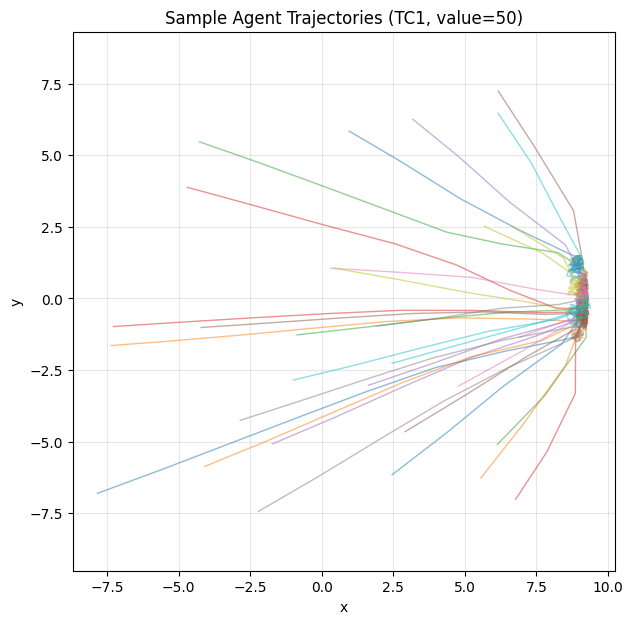

In [9]:
# where agents go: sample trajectories
sample_agents = 30
selected_value = values[0] if changed_var != "control" else "control"

plot_df = df_traj[
    (df_traj["changed_value"] == selected_value)
    & (df_traj["model"] == "group")
    & (df_traj["run"] == 1)
].copy()

if len(plot_df) == 0:
    print("No trajectory rows found for selected filter.")
else:
    uniq_ids = plot_df["agent_id"].drop_duplicates()
    k = min(sample_agents, len(uniq_ids))
    keep_ids = uniq_ids.sample(k, random_state=42)
    plot_df = plot_df[plot_df["agent_id"].isin(keep_ids)]

    plt.figure(figsize=(7, 7))
    for aid, g in plot_df.groupby("agent_id"):
        plt.plot(g["x"], g["y"], alpha=0.5, linewidth=1)

    plt.title(f"Sample Agent Trajectories ({ACTIVE_TC}, value={selected_value})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.show()
